In [ ]:
### THIS IS A FIRST, "NAIVE" VERSION (v1) OF THE CODE THAT LOADS THE 3D ARRAYS DIRECTLY, DOES SOME ALGEBRA ON THEM, AND PLOTS SLICES. 
### IT'S FINE FOR R1P1 BUTTRUGGLES WITH ANYTHING LARGER BECAUSE IT'S VERY QUICKLY MEMORY LIMITED.
### IMPROVED IN adrienVisualizeDataLazy.ipynb (lazy loading) and further in adrienVisualizeData.ipynb
### ALL ROUTINES ARE IN adrienUtils.py and the case parameters and file paths are in adrienParamClassSheared.py
###  A. Lefauve,  January 2026

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import adrienParamClassSheared as params
import adrienUtils as utils

In [12]:
# Force refresh if needed
importlib.reload(utils)
importlib.reload(params)

<module 'adrienParamClassSheared' from '/autofs/nccs-svm1_home2/lefauve/git/INCITE/adrien/adrienParamClassSheared.py'>

In [3]:
# Load in simulation parameters from the parameter list
pList = params.generate()
p = pList["R1P7"]

x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)

In [4]:
p.Nx

3072

In [7]:
# Load in actual simulation data  and check size
r = utils.load_binary("r",p)
b = -p.zAccel*r # buoyancy from density
del r
u = utils.load_binary("u",p)
v = utils.load_binary("v",p)
w = utils.load_binary("w",p)
u.shape

(3072, 1536, 768)

In [8]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

b                          13.50 GB  shape=(3072, 1536, 768)  dtype=float32
u                          13.50 GB  shape=(3072, 1536, 768)  dtype=float32
v                          13.50 GB  shape=(3072, 1536, 768)  dtype=float32
w                          13.50 GB  shape=(3072, 1536, 768)  dtype=float32

Notebook memory used     :  13.59 GB ( 10.6 %)
Remaining available to me: 114.41 GB ( 89.4 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [20]:
#eps = utils.compute_eps(p,u,v,w)
eps = utils.load_binary("ee",p)
subsample = 2
eps2 = eps[::subsample , ::subsample , ::subsample ]
eps_avg = np.mean(eps2)

In [19]:
#chi = utils.compute_chi(p,b)
chi = utils.load_binary("chi",p)
#chi_avg = np.mean(chi)
subsample = 2
chi2 = chi[::subsample , ::subsample , ::subsample ]
chi_avg = np.mean(chi2)

In [17]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

(No NumPy arrays above threshold)

Notebook memory used     :   0.13 GB (  0.1 %)
Remaining available to me: 127.87 GB ( 99.9 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [21]:
print(f"<ε> = {eps_avg:.2e}")
print(f"<χ> = {chi_avg:.2e}")
print(f"max(ε/<ε>) = {np.max(eps2[:, :, :]/eps_avg):.0f}")
print(f"max(χ/<χ>) = {np.max(chi2[:, :, :]/chi_avg):.0f}")

<ε> = 2.87e-03
<χ> = 4.38e-04
max(ε/<ε>) = 119
max(χ/<χ>) = 334


In [23]:
# Compute average quantities 
Gamma = chi_avg/eps_avg 
N2 = -p.dGrad*p.zAccel
Ri = N2
Reb = eps_avg/(p.kinV*N2)
# AVOID COMPUTING Ek AS IT'S TOO SLOW ON BIG DATASETS
#Ek = np.mean((u.flatten())**2+(v.flatten())**2+(w.flatten())**2)/2
#Ek_pct = 100 * Ek / p.targKE
Ek = p.targKE
# COMPUTE EP ESTIMATE BUT SUBSAMPLE
subsample = 2
b2 = b[::subsample , ::subsample , ::subsample ]
Ep = (b2*b2).mean() / (2*N2)
RPK = Ep/Ek

print(f"Ri = {Ri:.3f}")
print(f"Γ = {Gamma:.3f}")
print(f"Reb = {Reb:.1f}")
#print(f"Measured Ek = {Ek:.3e} ({Ek_pct:.2f}% of target)")
#print(f"Measured Ep = {Ep:.3e}")
print(f"RPK = {RPK:.2f}")

Ri = 0.153
Γ = 0.153
Reb = 37.5
RPK = 0.19


In [ ]:
# Plot XZ slices of the PERTURBATIONS

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 2

fig, axs = plt.subplots(6, 1, figsize=(10, 16))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$u'/E_k^{1/2}$")
axs[0].set_title(f"$u'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$w'/E_k^{1/2}$")
axs[1].set_title(f"$v'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$w'/E_k^{1/2}$")
axs[2].set_title(f"$w'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :]/np.sqrt(N2*Ep), "viridis", -5, 5, "$b'/(NE_p^{1/2})$")
axs[3].set_title(f"$b'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[4], np.log10(eps[:, yIdx, :]/eps_avg), "magma", -2, 2, "log₁₀ (ε/<ε>)")
axs[4].set_title(f"ε(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[4], "x", p.Nx, "x index")
utils.set_index_axis(axs[4], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[5], np.log10(chi[:, yIdx, :]/chi_avg), "hot", -2, 2, "log₁₀ (χ/<χ>)")
axs[5].set_title(f"χ(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[5], "x", p.Nx, "x index")
utils.set_index_axis(axs[5], "y", p.Nz, "z index")

In [ ]:
# Plot XZ slices of the TOTAL FIELDS

# Define background fields U(z) = z and B(z) = N^2 * z = Ri * z
dz = p.Lz/p.Nz
z_centre = (np.arange(p.Nz) - p.Nz/2)*dz # so that z=0 in the middle
Uz = z_centre;
Bz = -p.dGrad * p.zAccel * z_centre # equivalently, N2*z_centre

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 4

fig, axs = plt.subplots(4, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :] + Uz, "seismic", -4, 4, "u_total");  
axs[0].set_title(f"u_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v"); 
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w");  
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :] + Bz, "viridis", -4*Ri, 4*Ri, "ρ_total");  
axs[3].set_title(f"ρ_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")
utils.set_index_axis(axs[3], "x", p.Nx, "x index")

In [54]:
# Save figure 
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="png",
    dpi=500
)

PosixPath('figures/R1P1_slice_y192_20260130_082020.png')

In [86]:
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="png",
    dpi=300
)

Saved -> figures/R1P1_slice_y192_20260130_063413.jpg


PosixPath('figures/R1P1_slice_y192_20260130_063413.jpg')

In [24]:
print("u_total min:", np.min(u[:, yIdx, :] + Uz))
print("u_total max:", np.max(u[:, yIdx, :] + Uz))
print("b_total min:", np.min(b[:, yIdx, :] + Bz))
print("b_total max:", np.max(b[:, yIdx, :] + Bz))

NameError: name 'yIdx' is not defined

Saved -> figures/R1P7_all_variables_z384_20260130_102334.png


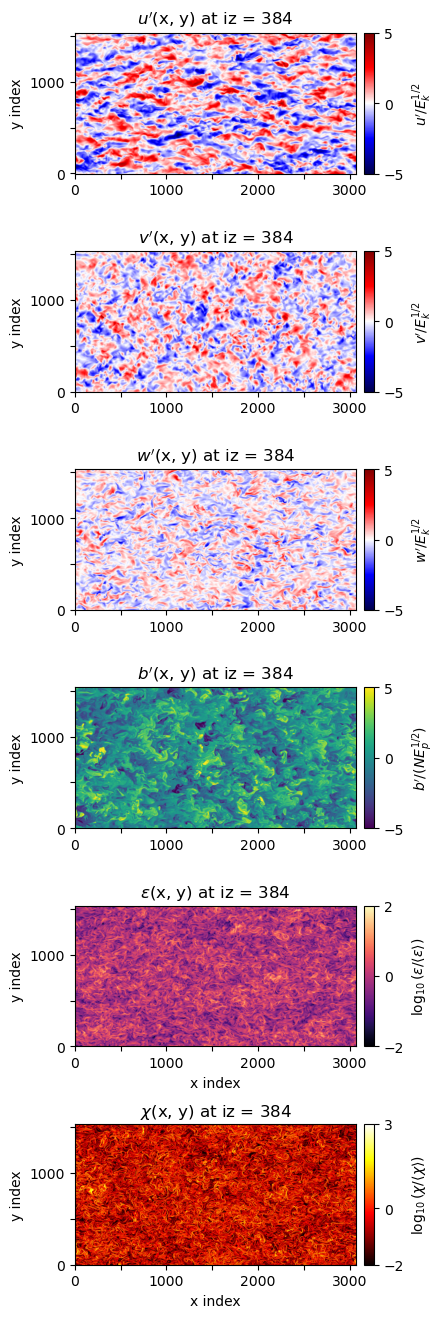

In [25]:
# EXPORT ALL FIVE KEY VARIABLES AS A SUMMARY FIGURE (exported resolution much lower than grid)
# Plot any xy, xz, yz slice of the perturbations 
# If force refresh of adrienUtils is needed
import adrienUtils
importlib.reload(adrienUtils)

# XY mid slice
fig, axs = utils.plot_slices_all_vars(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="xy", idx=p.Nz//2,
    save=True, outdir="figures", fmt="png", dpi=300
)

Saved -> figures/R1P1_all_variables_y384_20260130_094414.png


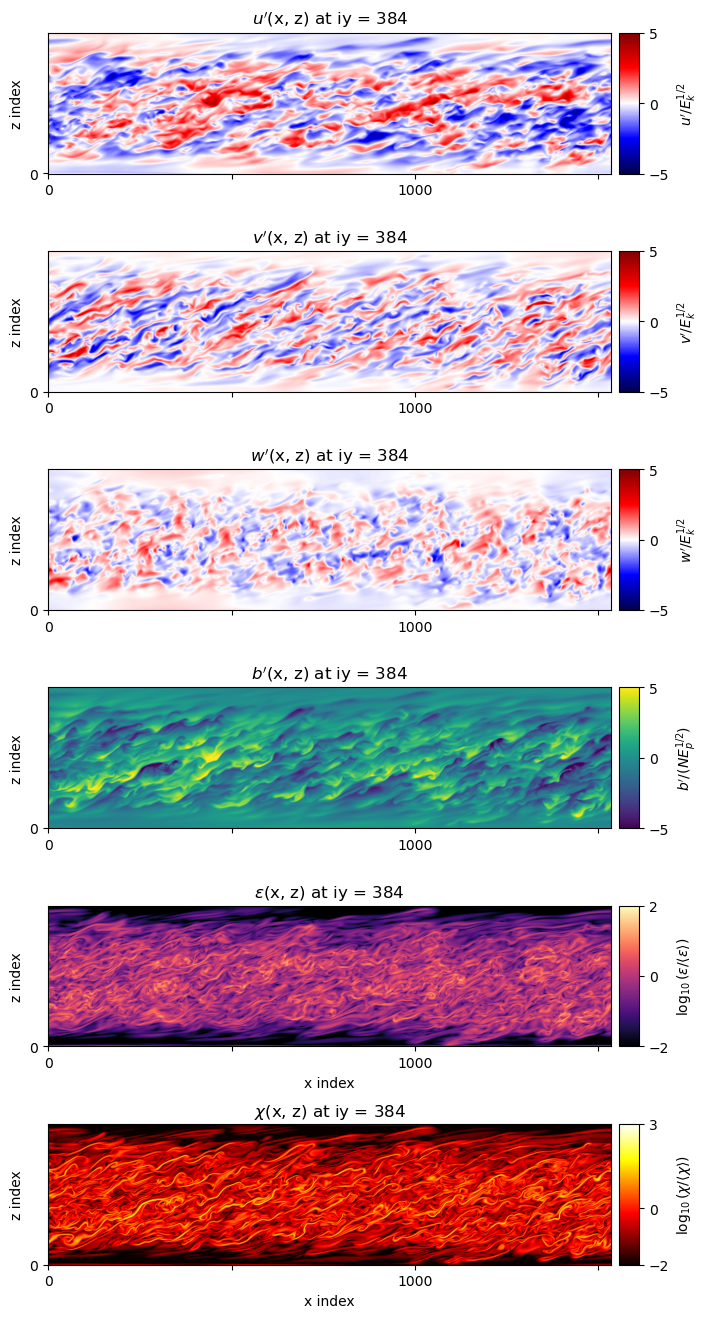

In [15]:
# Plot any xy, xz, yz slice of the perturbations 
# If force refresh of adrienUtils is needed
import adrienUtils
importlib.reload(adrienUtils)

# XZ mid slice
fig, axs = utils.plot_slices_all_vars(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="xz", idx=p.Ny//2,
    save=True, outdir="figures", fmt="png", dpi=300
)

In [ ]:
# Plot any xy, xz, yz slice of the perturbations 
# If force refresh of adrienUtils is needed
import adrienUtils
importlib.reload(adrienUtils)

# YZ mid slice
fig, axs = utils.plot_slices_all_vars(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="yz", idx=p.Nx//2,
    save=True, outdir="figures", fmt="png", dpi=300
)

In [17]:
# EXPORT INDIVIDUAL VARIABLES IN NATIVE RESOLUTION (1 GRID POINT = 1 PIXEL)

import adrienUtils
importlib.reload(adrienUtils)
paths = utils.plot_slices_native_resolution(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="xy", idx=p.Nz//2,
    outdir="figures"
)
paths

{'u': 'figures/R1P1_u_native_res_z192_20260130_094815.png',
 'v': 'figures/R1P1_v_native_res_z192_20260130_094815.png',
 'w': 'figures/R1P1_w_native_res_z192_20260130_094815.png',
 'b': 'figures/R1P1_b_native_res_z192_20260130_094815.png',
 'e': 'figures/R1P1_e_native_res_z192_20260130_094815.png',
 'c': 'figures/R1P1_c_native_res_z192_20260130_094815.png'}

In [13]:
importlib.reload(utils)
paths = utils.plot_slices_native_resolution(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="xz", idx=p.Ny//2,
    outdir="figures",
    u_lim=(-5, 5),
    v_lim=(-5, 5),
    w_lim=(-5, 5),
    b_lim=(-5, 5),
    eps_lim=(-3, 3),
    chi_lim=(-2, 3),
)
paths

{'u': 'figures/R1P1_u_native_res_y384_20260130_094115.png',
 'v': 'figures/R1P1_v_native_res_y384_20260130_094115.png',
 'w': 'figures/R1P1_w_native_res_y384_20260130_094115.png',
 'b': 'figures/R1P1_b_native_res_y384_20260130_094115.png',
 'e': 'figures/R1P1_e_native_res_y384_20260130_094115.png',
 'c': 'figures/R1P1_c_native_res_y384_20260130_094115.png'}

In [18]:
importlib.reload(utils)
paths = utils.plot_slices_native_resolution(
    p, u, v, w, b, eps, chi,
    Ek=Ek, Ep=Ep, N2=N2,
    eps_avg=eps_avg, chi_avg=chi_avg,
    plane="yz", idx=p.Nx//2,
    outdir="figures"
)
paths

{'u': 'figures/R1P1_u_native_res_x768_20260130_094826.png',
 'v': 'figures/R1P1_v_native_res_x768_20260130_094826.png',
 'w': 'figures/R1P1_w_native_res_x768_20260130_094826.png',
 'b': 'figures/R1P1_b_native_res_x768_20260130_094826.png',
 'e': 'figures/R1P1_e_native_res_x768_20260130_094826.png',
 'c': 'figures/R1P1_c_native_res_x768_20260130_094826.png'}

u2 shape: (384, 96)
min/max: -0.596762478351593 0.5546532273292542


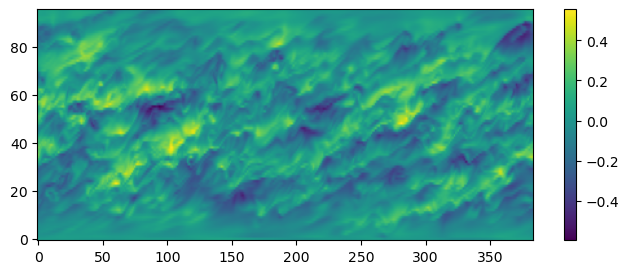

In [16]:
# Lazy loading test

from adrienUtils import open_lazy_fields
import matplotlib.pyplot as plt

fields = utils.open_lazy_fields(["u", "v", "w", "r", "ee", "chi"], p)

plane = "xz"
idx = p.Ny // 2
stride = (8, 1, 8)

u2 = fields["u"].slice2d(plane=plane, idx=idx, stride=stride)

print("u2 shape:", u2.shape)
print("min/max:", float(u2.min()), float(u2.max()))

plt.figure(figsize=(8, 3))
plt.imshow(u2.T, origin="lower", aspect="auto")
plt.colorbar()
plt.show()